In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())

# Simple Imputation: Fill missing BMI values with the median
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

Missing Values per Column:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [3]:
#Encoding and Correlation

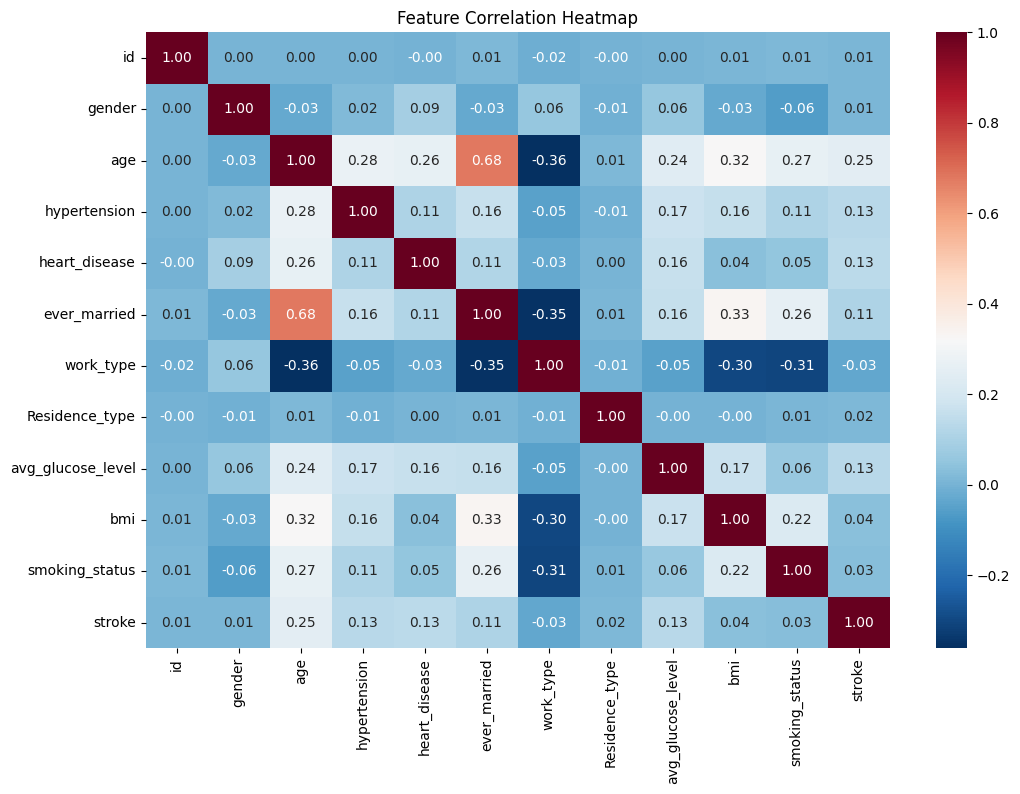

In [2]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Encode categorical columns
le = LabelEncoder()
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Show Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [4]:
#Data Distribution (Bar Plots)

/tmp/ipython-input-2960467993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


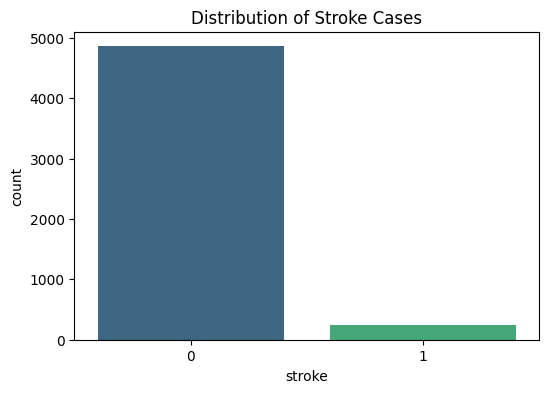

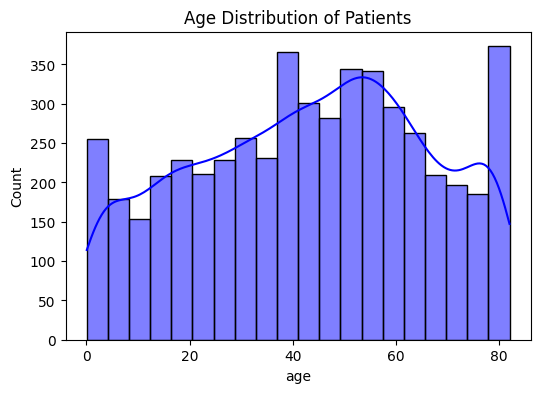

In [5]:
# Distribution of the Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribution of Stroke Cases')
plt.show()

# Distribution of Age
plt.figure(figsize=(6, 4))
sns.histplot(df['age'], kde=True, color='blue')
plt.title('Age Distribution of Patients')
plt.show()

In [8]:
#Modeling: Classical vs. Neural Network

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import tensorflow as tf

# Prepare Features and Target
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Scale the data (crucial for Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# --- Classical Model: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Neural Network Model ---
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = nn_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
nn_preds = (nn_model.predict(X_test) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [11]:
#Performance Comparison

Random Forest Accuracy: 0.9384
Neural Network Accuracy: 0.9393


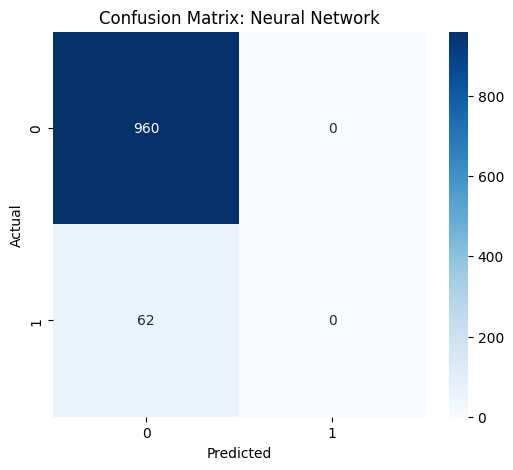

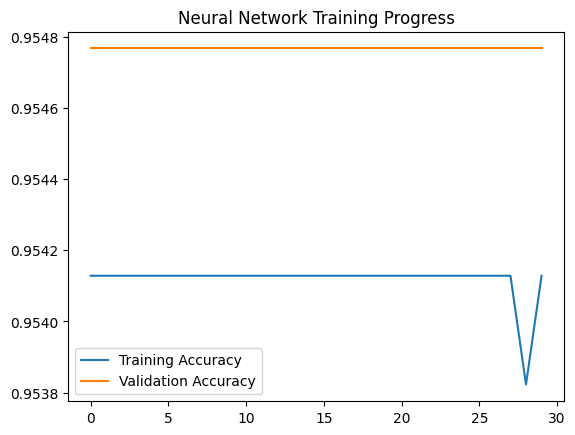

In [14]:
# Plot Accuracy Comparison
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Neural Network Accuracy: {accuracy_score(y_test, nn_preds):.4f}")

# Plot Confusion Matrix for Neural Network
cm = confusion_matrix(y_test, nn_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Neural Network')
plt.show()

# Plot Training History
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Training Progress')
plt.legend()
plt.show()

In [15]:
#Feature Engineering (Medical Domain Logic)

In [16]:
#BMI Categories: Based on WHO guidelines (Underweight, Normal, Overweight, Obese) [1].

#Glucose Status: Categorized using ADA diagnostic criteria (Normal, Pre-diabetic, Diabetic) [2].

In [19]:
import pandas as pd
import numpy as np

# Load and clean
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

def apply_feature_engineering(df):
    # 1. BMI Categorization (WHO Standards)
    # Underweight: <18.5, Normal: 18.5-24.9, Overweight: 25-29.9, Obese: >30
    df['bmi_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 24.9, 29.9, 100],
                           labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

    # 2. Glucose Categorization (ADA Standards)
    # Normal: <100, Pre-diabetic: 100-125, Diabetic: >125
    df['glucose_status'] = pd.cut(df['avg_glucose_level'], bins=[0, 100, 125, 1000],
                                  labels=['Normal', 'Pre-diabetic', 'Diabetic'])

    # 3. Composite Health Risk Score (Sum of existing conditions)
    df['health_risk_count'] = df['hypertension'] + df['heart_disease']

    # 4. Age Binning (Stroke risk increases significantly after 55)
    df['age_group'] = pd.cut(df['age'], bins=[0, 18, 45, 60, 100],
                             labels=['Child', 'Adult', 'Middle-Aged', 'Senior'])
    return df

df = apply_feature_engineering(df)

In [20]:
#Data Balancing with SMOTE

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Encoding categorical data
le = LabelEncoder()
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type',
                    'smoking_status', 'bmi_cat', 'glucose_status', 'age_group']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Prepare features
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Scaling (Vital for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

/tmp/ipython-input-3284164754.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette='viridis', edgecolor='black')
/tmp/ipython-input-3284164754.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res, ax=axes[1], palette='magma', edgecolor='black')


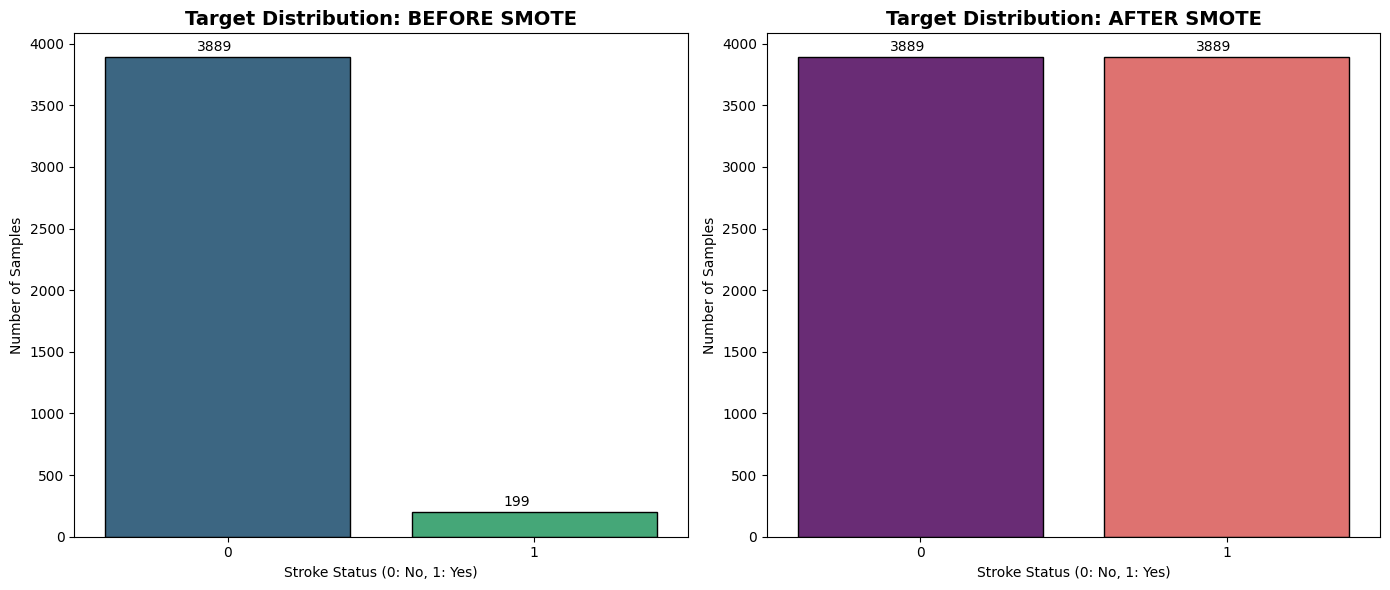

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# 1. Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# 2. Setup Plotting Environment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Before SMOTE ---
sns.countplot(x=y_train, ax=axes[0], palette='viridis', edgecolor='black')
axes[0].set_title('Target Distribution: BEFORE SMOTE', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stroke Status (0: No, 1: Yes)')
axes[0].set_ylabel('Number of Samples')

# Adding text labels for clarity
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

# --- Plot 2: After SMOTE ---
sns.countplot(x=y_res, ax=axes[1], palette='magma', edgecolor='black')
axes[1].set_title('Target Distribution: AFTER SMOTE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stroke Status (0: No, 1: Yes)')
axes[1].set_ylabel('Number of Samples')

# Adding text labels
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

plt.tight_layout()
plt.show()

In [22]:
#Re-training and Metrics

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


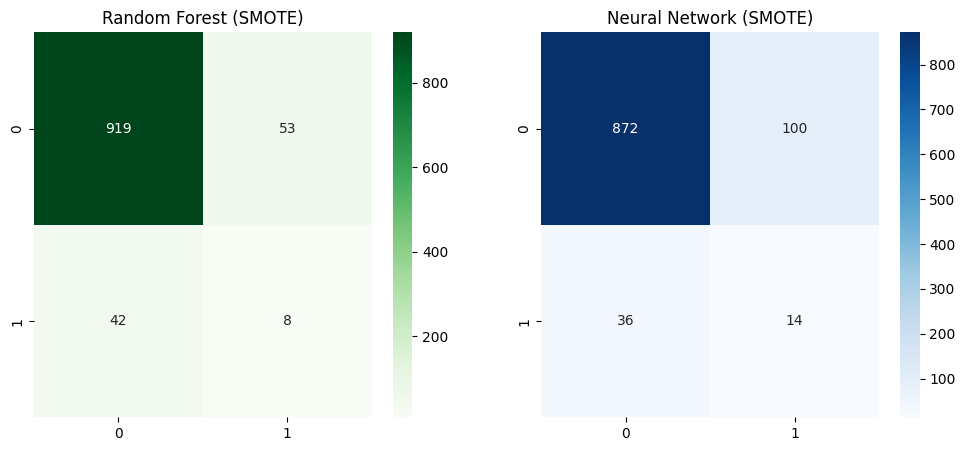

Random Forest Performance:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.13      0.16      0.14        50

    accuracy                           0.91      1022
   macro avg       0.54      0.55      0.55      1022
weighted avg       0.92      0.91      0.91      1022

Neural Network Performance:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       972
           1       0.12      0.28      0.17        50

    accuracy                           0.87      1022
   macro avg       0.54      0.59      0.55      1022
weighted avg       0.92      0.87      0.89      1022



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Classical Model: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
rf_preds = rf.predict(X_test)

# 2. Neural Network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train_res, epochs=50, batch_size=32, validation_split=0.1, verbose=0)
nn_preds = (model.predict(X_test_scaled) > 0.5).astype(int)

# Visualization: Confusion Matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest (SMOTE)')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, nn_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Neural Network (SMOTE)')
plt.show()

# Show Classification Reports
print("Random Forest Performance:\n", classification_report(y_test, rf_preds))
print("Neural Network Performance:\n", classification_report(y_test, nn_preds))

In [26]:
# engineer new feature: stress

In [27]:
#We will assign "Stress Points" based on the following criteria:

 #   Work Type: "Self-employed" and "Private" sector roles often report higher psychological demand than "Govt_job" or "children" [2].

  #  Residence: Urban areas are linked to higher chronic stress due to noise, pollution, and pace [3].

   # Age: Research shows a "U-shaped" stress curve, where stress peaks in the 45–60 age bracket (Middle-Aged) due to career and family pressures.

In [25]:
def calculate_stress(row):
    score = 0

    # 1. Employment Stress
    if row['work_type'] == 'Self-employed':
        score += 3  # High risk/uncertainty
    elif row['work_type'] == 'Private':
        score += 2  # Standard corporate pressure
    elif row['work_type'] == 'Govt_job':
        score += 1  # Generally higher job security

    # 2. Residence Stress
    if row['Residence_type'] == 'Urban':
        score += 2
    else:
        score += 1

    # 3. Age-Related Stress (The "Middle-Age Peak")
    if 45 <= row['age'] <= 60:
        score += 3
    elif row['age'] > 60:
        score += 2
    else:
        score += 1

    # 4. Lifestyle Stress (Smoking)
    if row['smoking_status'] in ['smokes', 'formerly smoked']:
        score += 2

    return score

# Apply the feature engineering
df['stress_score'] = df.apply(calculate_stress, axis=1)

# Normalize the score between 0 and 1 for the Neural Network
df['stress_score_norm'] = (df['stress_score'] - df['stress_score'].min()) / \
                          (df['stress_score'].max() - df['stress_score'].min())

In [28]:
def calculate_stress(row):
    score = 0
    # Work Stress: Self-employed (3), Private (2), Govt (1), others (0)
    work_map = {'Self-employed': 3, 'Private': 2, 'Govt_job': 1}
    score += work_map.get(row['work_type'], 0)

    # Environment Stress: Urban (2), Rural (1)
    score += 2 if row['Residence_type'] == 'Urban' else 1

    # Age-related stress: Peak "Sandwich Generation" (45-60)
    if 45 <= row['age'] <= 60: score += 3
    elif row['age'] > 60: score += 2
    else: score += 1

    return score

df['stress_score'] = df.apply(calculate_stress, axis=1)

/tmp/ipython-input-2863271869.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_stroke.values, y=correlation_with_stroke.index, palette='coolwarm')


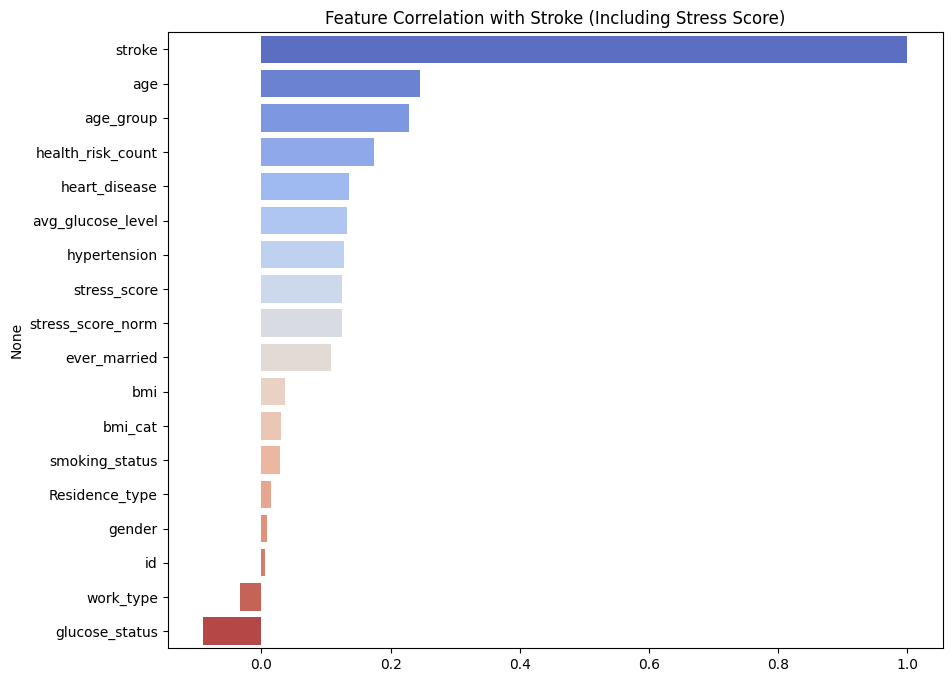

In [29]:
plt.figure(figsize=(10, 8))
# Focusing correlation on the 'stroke' target
correlation_with_stroke = df.corr()['stroke'].sort_values(ascending=False)
sns.barplot(x=correlation_with_stroke.values, y=correlation_with_stroke.index, palette='coolwarm')
plt.title('Feature Correlation with Stroke (Including Stress Score)')
plt.show()

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf

# Data Preparation
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']

# Scale features for the Neural Network
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE locally
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# --- Neural Network ---
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train, y_train, epochs=50, verbose=0)
nn_preds = (nn_model.predict(X_test) > 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Random Forest Accuracy: 0.967095115681234
Neural Network Accuracy: 0.9408740359897172


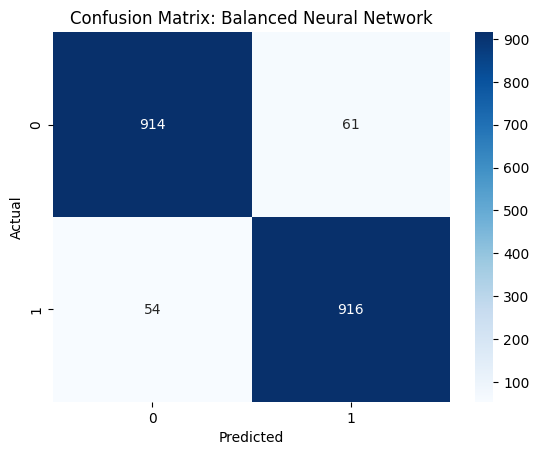

In [31]:
from sklearn.metrics import confusion_matrix

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Neural Network Accuracy:", accuracy_score(y_test, nn_preds))

# Plotting the Confusion Matrix for the Neural Network
cm = confusion_matrix(y_test, nn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Balanced Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()